# Analyse des résultats sauvegardés

Ce notebook affiche les courbes de loss et compare les performances des modèles de classification binaire préalablement entrainées. Les résultats ont étés sauvegardés dans `models/temp_results/classification`.

On considère ici 4 modèles: 
- CNN simple composé de 4 blocks de convolution 3*3
- CNN simple avec data augmentation
- VGG transfert learning: le CNN profond pré-entrainé VGG16 auquel on a ajouté une tête de classification
- VGG finetuned: VGG transfert learning avec les 3 dernier paramètre de VGG 16 dégelés, les poids sont recalculés pour ce modèle. 

In [1]:
# 1. Importer les bibliothèques nécessaires
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

### Charger les courbes de loss sauvegardées
On charge les fichiers .npy ou .pt contenant les courbes de loss pour chaque modèle.

In [2]:
# 2. Charger les courbes de loss sauvegardées
results_dir = 'models/temp_results/classification'

model_names = {
    'cnn': 'cnn',
    'cnn_aug': 'cnn_data_augmentation',
    'vgg_full_finetune': 'vgg_full_finetune',
    'vgg_transfer': 'vgg_transferlearning'
}

loss_logs = {}
for key, subdir in model_names.items():
    path = os.path.join(results_dir, subdir, 'loss_log.npy')
    if os.path.exists(path):
        loss_logs[key] = np.load(path, allow_pickle=True).item()
    else:
        print(f"Fichier non trouvé pour {key}: {path}")

### Afficher les courbes de loss pour chaque modèle

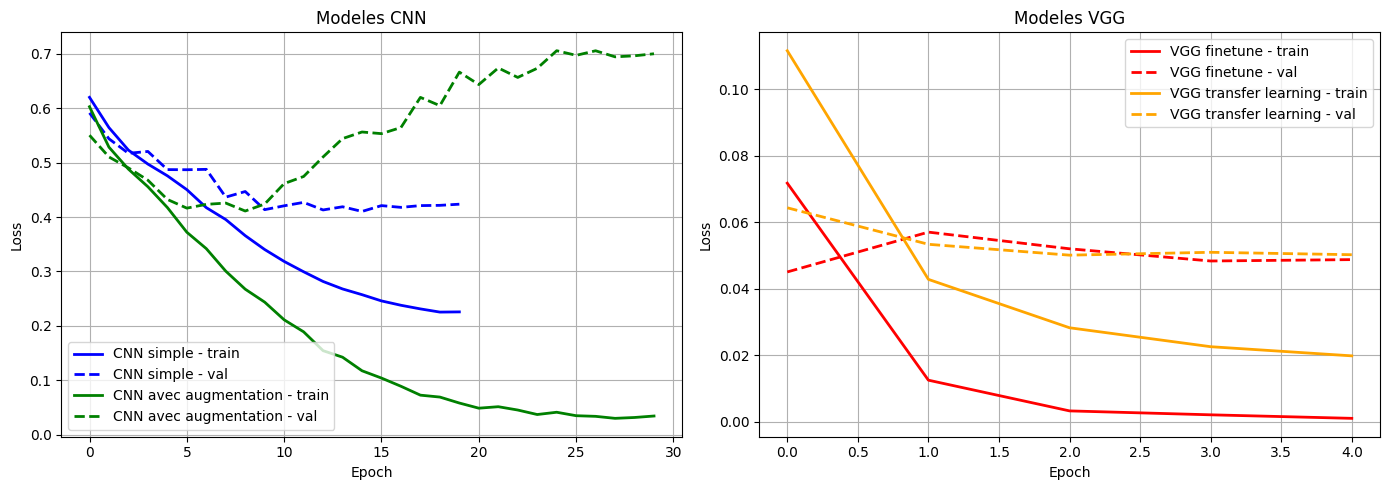

In [6]:
# 3. Afficher les courbes de loss pour chaque modèle
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique CNN
cnn_models = {'cnn': 'CNN simple', 'cnn_aug': 'CNN avec augmentation'}
colors_cnn = ['blue', 'green']
for i, (key, label) in enumerate(cnn_models.items()):
    if key in loss_logs:
        log = loss_logs[key]
        ax1.plot(log['train'], label=f'{label} - train', color=colors_cnn[i], linewidth=2)
        ax1.plot(log['val'], label=f'{label} - val', color=colors_cnn[i], linestyle='--', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Modeles CNN')
ax1.legend()
ax1.grid(True)

# Graphique VGG
vgg_models = {'vgg_full_finetune': 'VGG finetune', 'vgg_transfer': 'VGG transfer learning'}
colors_vgg = ['red', 'orange']
for i, (key, label) in enumerate(vgg_models.items()):
    if key in loss_logs:
        log = loss_logs[key]
        ax2.plot(log['train'], label=f'{label} - train', color=colors_vgg[i], linewidth=2)
        ax2.plot(log['val'], label=f'{label} - val', color=colors_vgg[i], linestyle='--', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Modeles VGG')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()



Les modèles VGG en transfer learning et en finetune donnent d’excellents résultats sans overfitting. Le CNN sans data augmentation fonctionne correctement, mais avec data augmentation, on observe de l’overfitting. Ce résultat est surprenant : une explication possible est que les transformations appliquées sont trop fortes ou inadaptées, ce qui rend les images du train trop différentes de la distribution réelle. Le modèle a alors du mal à généraliser et sur-apprend les exemples du train, ce qui dégrade ses performances en validation.

### Comparer les performances des modèles
On affiche la meilleure loss de validation atteinte pour chaque modèle dans un tableau récapitulatif.

              Modèle  Best Val Loss
2  vgg_full_finetune       0.045058
3       vgg_transfer       0.050105
0                cnn       0.410293
1            cnn_aug       0.411050


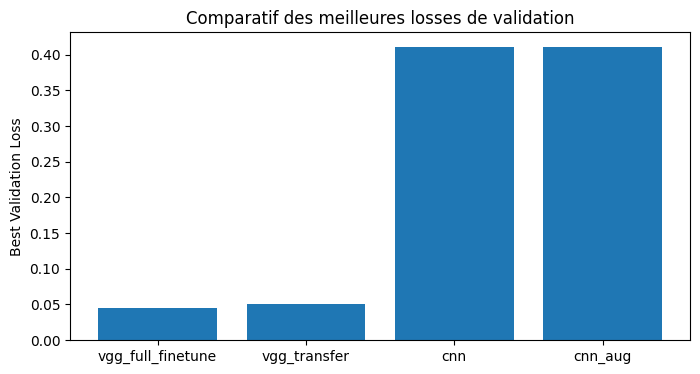

In [4]:
# 4. Comparer les performances des modèles
import pandas as pd

perf = []
for key, log in loss_logs.items():
    best_val = np.min(log['val'])
    perf.append({'Modèle': key, 'Best Val Loss': best_val})

perf_df = pd.DataFrame(perf)
perf_df = perf_df.sort_values('Best Val Loss')
print(perf_df)

plt.figure(figsize=(8,4))
plt.bar(perf_df['Modèle'], perf_df['Best Val Loss'])
plt.ylabel('Best Validation Loss')
plt.title('Comparatif des meilleures losses de validation')
plt.show()

### Evaluation sur le test set
Ici tous les modèles ont été évalués sur les poids correspondant à la loss la plus faible sur la validation. 

In [7]:
import torch.nn as nn
from dataloader_classification import get_oxford_loaders
from models.classification_binaire import ClassificationNetwork, MyVGGClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Charger les dataloaders
root_dir = './data/oxford-iiit-pet'
loaders = get_oxford_loaders(
    root_dir,
    task='classification',
    batch_size=16,
    dataset_variant='custom'
)
test_loader = loaders['test']

Device: cuda


In [8]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_curve, auc, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            
            # Pour classification binaire avec BCEWithLogitsLoss
            probs = torch.sigmoid(outputs.view(-1))
            preds = (probs > 0.5).long()
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)
    
    # Calcul des metriques
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'F1 Score: {f1:.4f}')
    
    # Courbe ROC
    fpr, tpr, _ = roc_curve(all_targets, all_probs)
    roc_auc = auc(fpr, tpr)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # ROC Curve
    ax1.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax1.plot([0, 1], [0, 1], 'k--', label='Random')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend()
    ax1.grid(True)
    
    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    ax2.set_title('Confusion Matrix')
    
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'f1': f1, 'auc': roc_auc}

### Evaluation CNN simple

CNN simple
Accuracy: 0.8190
Precision: 0.8735
F1 Score: 0.8655


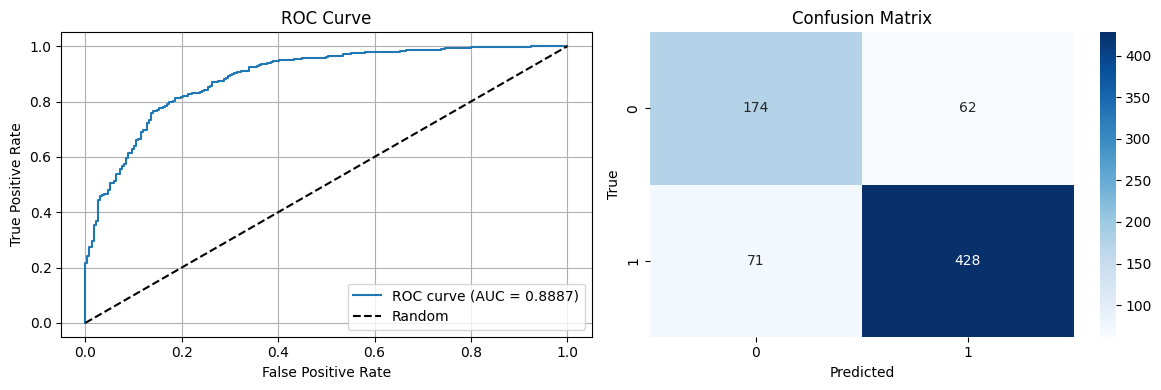

In [9]:
print('CNN simple')
model_cnn = ClassificationNetwork().to(device)
model_cnn.load_state_dict(torch.load('models/temp_results/classification/cnn/best.pth', map_location=device))
results_cnn = evaluate_model(model_cnn, test_loader, device)

### Evaluation CNN avec data augmentation

CNN avec data augmentation
Accuracy: 0.8259
Precision: 0.8778
F1 Score: 0.8707


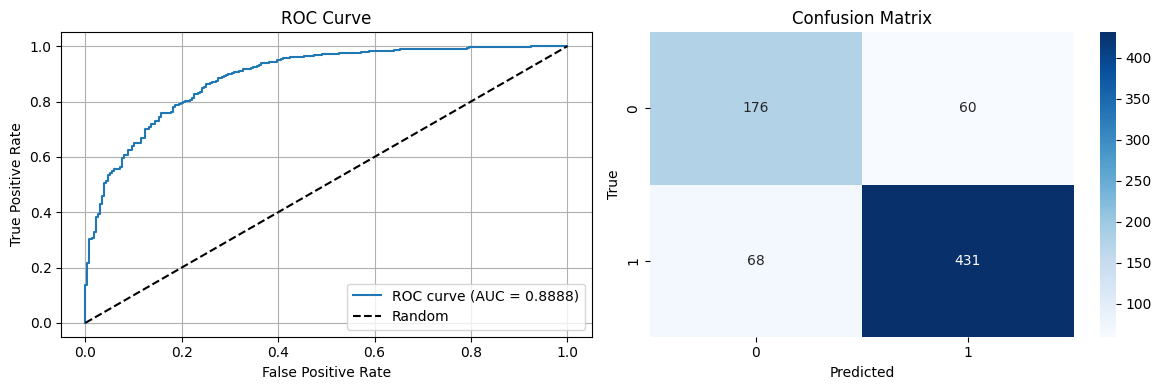

In [10]:
print('CNN avec data augmentation')
model_cnn_aug = ClassificationNetwork().to(device)
model_cnn_aug.load_state_dict(torch.load('models/temp_results/classification/cnn_data_augmentation/best.pth', map_location=device))
results_cnn_aug = evaluate_model(model_cnn_aug, test_loader, device)

### Evaluation VGG full finetune

VGG full finetune
Accuracy: 0.9823
Precision: 0.9939
F1 Score: 0.9869


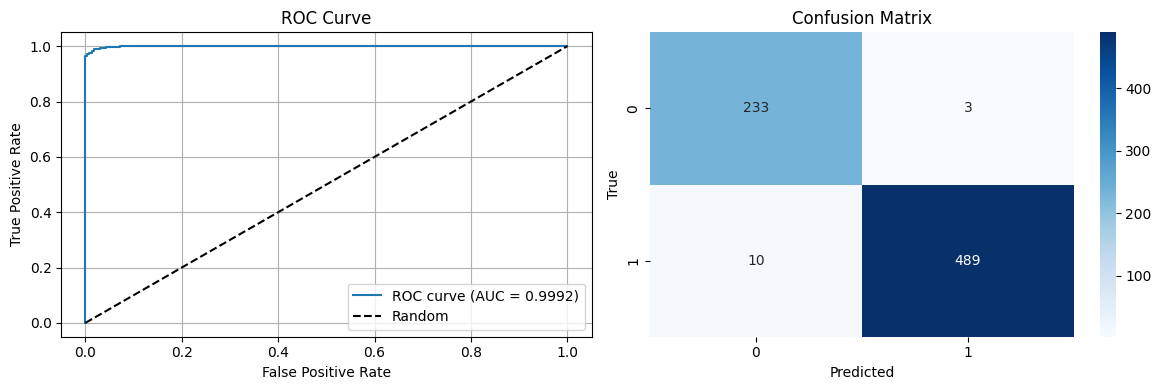

In [11]:
print('VGG full finetune')
model_vgg_finetune = MyVGGClassifier(freeze_base=True, finetune=True).to(device)
model_vgg_finetune.load_state_dict(torch.load('models/temp_results/classification/vgg_full_finetune/best.pth', map_location=device))
results_vgg_finetune = evaluate_model(model_vgg_finetune, test_loader, device)

### Evaluation VGG transfer learning

VGG transfer learning
Accuracy: 0.9769
Precision: 0.9859
F1 Score: 0.9829


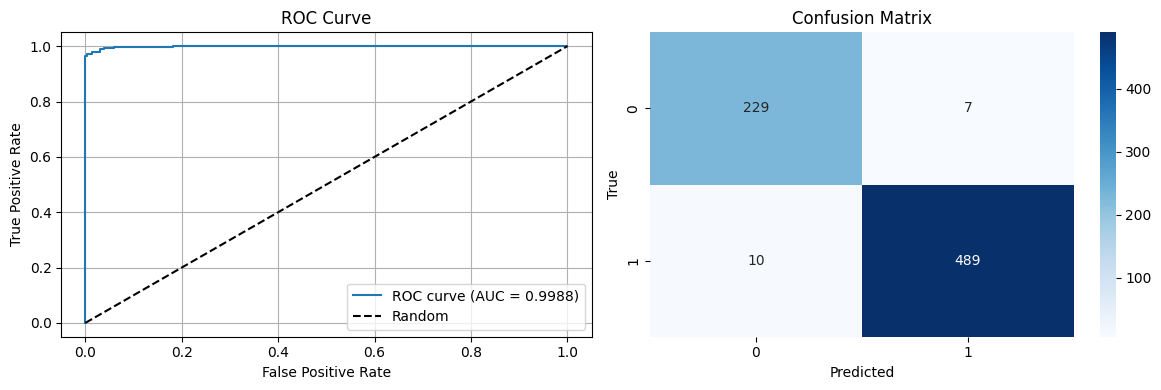

In [12]:
print('VGG transfer learning')
model_vgg_transfer = MyVGGClassifier(freeze_base=False).to(device)
model_vgg_transfer.load_state_dict(torch.load('models/temp_results/classification/vgg_transferlearning/best.pth', map_location=device))
results_vgg_transfer = evaluate_model(model_vgg_transfer, test_loader, device)

Les courbes ROC des modèles VGG sont quasi parfaites, témoignant d’une excellente capacité de discrimination. Celles des CNN sont également très bonnes, indiquant de bonnes performances de classification.

### Tableau recapitulatif des metriques


Tableau recapitulatif des performances sur le test set:
                       accuracy  precision        f1       auc
VGG finetune           0.982313   0.993902  0.986882  0.999219
VGG transfer learning  0.976871   0.985887  0.982915  0.998760
CNN avec augmentation  0.825850   0.877800  0.870707  0.888769
CNN simple             0.819048   0.873469  0.865521  0.888710


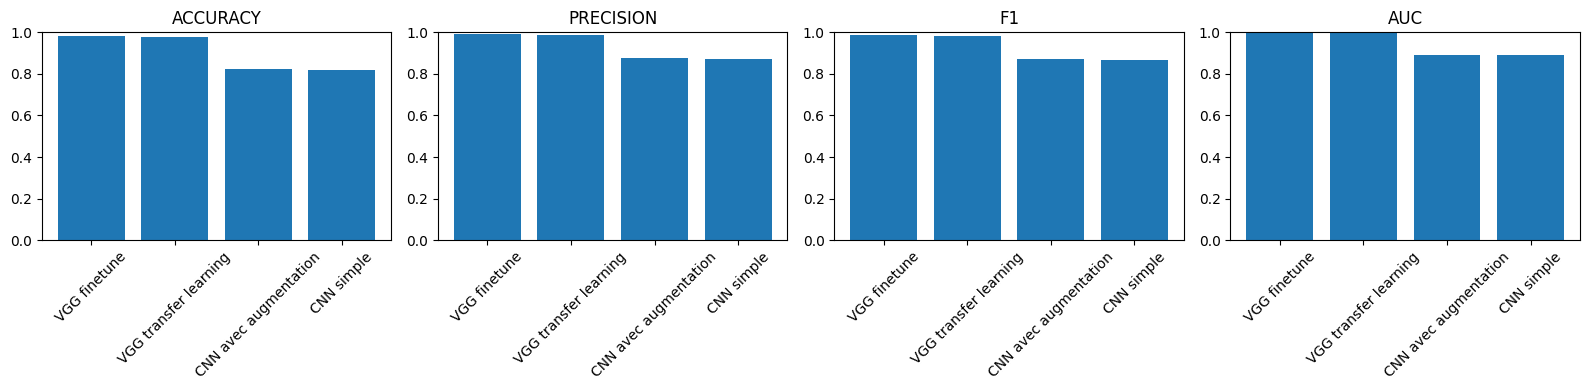

In [14]:
all_results = {
    'CNN simple': results_cnn,
    'CNN avec augmentation': results_cnn_aug,
    'VGG finetune': results_vgg_finetune,
    'VGG transfer learning': results_vgg_transfer
}

results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values('accuracy', ascending=False)
print('\nTableau recapitulatif des performances sur le test set:')
print(results_df)

# Graphique comparatif
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['accuracy', 'precision', 'f1', 'auc']
for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric])
    axes[i].set_title(metric.upper())
    axes[i].set_ylim([0, 1])
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Les modèles VGG (finetune et transfer learning) surpassent nettement les CNN, avec des scores d’accuracy, de précision, de F1 et d’AUC très élevés (tous >0.97).
Le VGG finetune, qui ajuste les 3 derniers paramètres du backbone, obtient les meilleurs résultats sur tous les indicateurs, légèrement devant le VGG transfer learning (où tous les paramètres du backbone sont gelés). Cela montre que permettre l’ajustement de quelques couches supplémentaires améliore la capacité du modèle à s’adapter à la tâche cible, ici classification binaire. 

Les deux CNN (avec et sans data augmentation) ont des performances similaires, nettement inférieures à celles des VGG, avec une accuracy autour de 0.82 et un AUC d’environ 0.89.
À noter : pour le CNN avec augmentation, les poids utilisés sont ceux correspondant à la meilleure loss de validation (avant overfitting), ce qui donne une vision optimiste de ses performances. Malgré cela, il reste en retrait par rapport aux VGG.

En résumé :
Les architectures VGG, même avec peu de fine-tuning, offrent une bien meilleure généralisation et capacité de discrimination que les CNN peu profonds que nous avons implémenté et entrainés.
Le fine-tuning partiel (3 couches) apporte un gain supplémentaire par rapport au simple transfert de features.
Les CNN restent limités sur ce jeu de données, même avec data augmentation.
